# PyTorch vehicle detector for oriented boxes

This notebook implements a complete CPU-friendly PyTorch pipeline for the task described in `docs/contex-en.md`.

Goal: detect and classify 9 vehicle classes in intersection images, then export predictions in this format:

`score category_id cx cy width height angle_deg`

The annotations use oriented boxes: `category_id cx cy width height angle_deg`. Images with no objects use `none`.

## 1. Environment and paths

Run this notebook from the project root or from `pytorch-implementation/` after activating your CPU environment:

```bash
conda activate myenv
jupyter notebook pytorch-implementation/computer-vision.ipynb
```

In [1]:
from pathlib import Path
import csv
import math
import random
import time

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
from torchvision.ops import nms

print('torch:', torch.__version__)
print('device: cpu')

DEVICE = torch.device('cpu')
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'processed_300' / 'data_300.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_PATH = PROJECT_ROOT / 'data' / 'processed_300' / 'data_300.csv'
IMG_DIR = PROJECT_ROOT / 'data' / 'processed_300' / 'imgs'
OUTPUT_DIR = PROJECT_ROOT / 'pytorch-implementation' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.exists(), f'Missing annotations: {CSV_PATH}'
assert IMG_DIR.exists(), f'Missing image directory: {IMG_DIR}'

CLASS_NAMES = {
    1: 'Car',
    2: 'Van',
    3: 'Microbus',
    4: 'Minibus',
    5: 'Bus',
    6: 'Articulated Bus',
    7: 'Truck',
    8: 'Mototaxi',
    9: 'Motorcycle',
}
NUM_CLASSES = len(CLASS_NAMES)
print('project root:', PROJECT_ROOT)
print('classes:', CLASS_NAMES)

torch: 2.12.1+cpu
device: cpu
project root: /home/totora/Documents/PROFESIONAL/swole-yolo
classes: {1: 'Car', 2: 'Van', 3: 'Microbus', 4: 'Minibus', 5: 'Bus', 6: 'Articulated Bus', 7: 'Truck', 8: 'Mototaxi', 9: 'Motorcycle'}


## 2. Parse the annotation CSV

Each row has an image id and either `none` or one or more semicolon-separated boxes. The parser below keeps the original pixel coordinates so predictions can be exported in the same coordinate system.

In [2]:
def parse_target(target_text):
    if target_text is None or target_text.strip().lower() == 'none':
        return []

    boxes = []
    for item in target_text.split(';'):
        parts = item.strip().split()
        if not parts:
            continue
        if len(parts) != 6:
            raise ValueError(f'Expected 6 values per annotation, got {len(parts)}: {item}')
        cls_id = int(float(parts[0]))
        cx, cy, w, h, angle = map(float, parts[1:])
        boxes.append({
            'class_id': cls_id,
            'cx': cx,
            'cy': cy,
            'w': w,
            'h': h,
            'angle': angle,
        })
    return boxes


def load_rows(csv_path):
    rows = []
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_path = IMG_DIR / f"{row['Id']}.jpg"
            rows.append({
                'id': row['Id'],
                'image_path': image_path,
                'boxes': parse_target(row['Target']),
            })
    return rows


rows = load_rows(CSV_PATH)
num_boxes = sum(len(r['boxes']) for r in rows)
num_empty = sum(1 for r in rows if not r['boxes'])
print(f'images: {len(rows)}')
print(f'annotated objects: {num_boxes}')
print(f'empty frames: {num_empty}')
print('sample:', rows[0])

images: 300
annotated objects: 3240
empty frames: 17
sample: {'id': 'v_cec6zlvav9_0038', 'image_path': PosixPath('/home/totora/Documents/PROFESIONAL/swole-yolo/data/processed_300/imgs/v_cec6zlvav9_0038.jpg'), 'boxes': []}


## 3. Encode oriented boxes for dense detection

For a compact CPU baseline, the model predicts one object per grid cell. Each positive cell stores:

`objectness, class, x_offset, y_offset, log_width, log_height, sin(angle), cos(angle)`

Angles are learned as sine/cosine so the model does not see a hard discontinuity between 359 degrees and 0 degrees.

In [3]:
IMG_SIZE = 512
STRIDE = 16
GRID_SIZE = IMG_SIZE // STRIDE
BATCH_SIZE = 4


def encode_targets(boxes, orig_w, orig_h):
    objectness = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32)
    classes = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.long)
    box_values = torch.zeros((GRID_SIZE, GRID_SIZE, 6), dtype=torch.float32)
    area_map = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32)

    sx = IMG_SIZE / orig_w
    sy = IMG_SIZE / orig_h

    for box in boxes:
        cx = box['cx'] * sx
        cy = box['cy'] * sy
        w = max(box['w'] * sx, 1.0)
        h = max(box['h'] * sy, 1.0)
        gx = min(max(int(cx / STRIDE), 0), GRID_SIZE - 1)
        gy = min(max(int(cy / STRIDE), 0), GRID_SIZE - 1)
        area = w * h

        # If two centers land in the same cell, keep the larger object.
        if objectness[gy, gx] == 1 and area <= area_map[gy, gx]:
            continue

        objectness[gy, gx] = 1.0
        classes[gy, gx] = box['class_id'] - 1
        area_map[gy, gx] = area

        x_offset = cx / STRIDE - gx
        y_offset = cy / STRIDE - gy
        angle_rad = math.radians(box['angle'])
        box_values[gy, gx] = torch.tensor([
            x_offset,
            y_offset,
            math.log(w / IMG_SIZE),
            math.log(h / IMG_SIZE),
            math.sin(angle_rad),
            math.cos(angle_rad),
        ], dtype=torch.float32)

    return {
        'objectness': objectness,
        'classes': classes,
        'boxes': box_values,
    }


class VehicleDataset(Dataset):
    def __init__(self, rows, train=True):
        self.rows = rows
        self.train = train

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        image = Image.open(row['image_path']).convert('RGB')
        orig_w, orig_h = image.size
        image = image.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

        if self.train and random.random() < 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.85, 1.15))
            image = TF.adjust_contrast(image, random.uniform(0.85, 1.15))

        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        target = encode_targets(row['boxes'], orig_w, orig_h)

        return image_tensor, target, {
            'id': row['id'],
            'orig_w': orig_w,
            'orig_h': orig_h,
        }


def collate_fn(batch):
    images, targets, metas = zip(*batch)
    return (
        torch.stack(images),
        {
            'objectness': torch.stack([t['objectness'] for t in targets]),
            'classes': torch.stack([t['classes'] for t in targets]),
            'boxes': torch.stack([t['boxes'] for t in targets]),
        },
        list(metas),
    )


full_dataset = VehicleDataset(rows, train=True)
val_size = max(1, int(0.2 * len(full_dataset)))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)
val_dataset.dataset.train = False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

images, targets, metas = next(iter(train_loader))
print(images.shape)
print(targets['objectness'].shape, targets['classes'].shape, targets['boxes'].shape)

torch.Size([4, 3, 512, 512])
torch.Size([4, 32, 32]) torch.Size([4, 32, 32]) torch.Size([4, 32, 32, 6])


## 4. Define a small PyTorch detector

The network downsamples the input by 16 and predicts, for every grid cell, objectness, 9 class logits, and 6 box-angle values.

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class TinyOrientedDetector(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(3, 24, stride=2),
            ConvBlock(24, 48, stride=2),
            ConvBlock(48, 96, stride=2),
            ConvBlock(96, 128, stride=2),
        )
        self.head = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(128, 1 + num_classes + 6, kernel_size=1),
        )

    def forward(self, x):
        out = self.head(self.backbone(x))
        out = out.permute(0, 2, 3, 1).contiguous()
        return {
            'objectness': out[..., 0],
            'classes': out[..., 1:1 + NUM_CLASSES],
            'boxes': out[..., 1 + NUM_CLASSES:],
        }


model = TinyOrientedDetector(NUM_CLASSES).to(DEVICE)
with torch.no_grad():
    sample_out = model(images.to(DEVICE))
print(sample_out['objectness'].shape, sample_out['classes'].shape, sample_out['boxes'].shape)

torch.Size([4, 32, 32]) torch.Size([4, 32, 32, 9]) torch.Size([4, 32, 32, 6])


## 5. Losses and training loop

The dataset has many background cells, so objectness uses a positive class weight. Classification and box regression losses only apply to cells that contain an object.

In [5]:
obj_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(20.0, device=DEVICE))
cls_loss_fn = nn.CrossEntropyLoss()
box_loss_fn = nn.SmoothL1Loss()


def detection_loss(pred, target):
    target_obj = target['objectness'].to(DEVICE)
    target_cls = target['classes'].to(DEVICE)
    target_box = target['boxes'].to(DEVICE)

    obj_loss = obj_loss_fn(pred['objectness'], target_obj)
    pos_mask = target_obj > 0.5

    if pos_mask.any():
        cls_loss = cls_loss_fn(pred['classes'][pos_mask], target_cls[pos_mask])
        box_loss = box_loss_fn(pred['boxes'][pos_mask], target_box[pos_mask])
    else:
        cls_loss = pred['classes'].sum() * 0.0
        box_loss = pred['boxes'].sum() * 0.0

    total = obj_loss + cls_loss + 5.0 * box_loss
    return total, {
        'total': float(total.detach().cpu()),
        'obj': float(obj_loss.detach().cpu()),
        'cls': float(cls_loss.detach().cpu()),
        'box': float(box_loss.detach().cpu()),
    }


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    totals = {'total': 0.0, 'obj': 0.0, 'cls': 0.0, 'box': 0.0}
    n = 0

    for images, targets, _ in loader:
        images = images.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(images)
            loss, parts = detection_loss(pred, targets)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)
        for key in totals:
            totals[key] += parts[key] * batch_size
        n += batch_size

    return {key: value / max(n, 1) for key, value in totals.items()}


optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 8

history = []
best_val = float('inf')
best_path = OUTPUT_DIR / 'tiny_oriented_detector_cpu.pt'

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_metrics = run_epoch(model, train_loader, optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)
    history.append({'epoch': epoch, 'train': train_metrics, 'val': val_metrics})

    if val_metrics['total'] < best_val:
        best_val = val_metrics['total']
        torch.save(model.state_dict(), best_path)

    elapsed = time.time() - start
    print(
        f"epoch {epoch:02d}/{EPOCHS} "
        f"train={train_metrics['total']:.4f} "
        f"val={val_metrics['total']:.4f} "
        f"time={elapsed:.1f}s"
    )

print('best checkpoint:', best_path)

epoch 01/8 train=2.1280 val=1.4991 time=20.1s
epoch 02/8 train=1.2347 val=1.2834 time=18.8s
epoch 03/8 train=1.0535 val=1.1453 time=20.0s
epoch 04/8 train=0.9819 val=1.0661 time=17.1s
epoch 05/8 train=0.9004 val=0.9791 time=17.6s
epoch 06/8 train=0.8327 val=0.9286 time=17.6s
epoch 07/8 train=0.6762 val=0.9686 time=17.5s
epoch 08/8 train=0.6316 val=0.8278 time=17.0s
best checkpoint: /home/totora/Documents/PROFESIONAL/swole-yolo/pytorch-implementation/outputs/tiny_oriented_detector_cpu.pt


## 6. Decode predictions back to the competition format

The decoder converts grid outputs back to original image pixels, applies a confidence threshold, and uses axis-aligned NMS as a practical duplicate filter. The exported boxes still keep the predicted angle.

In [6]:
def decode_predictions(pred, metas, conf_threshold=0.25, nms_threshold=0.45, max_detections=80):
    obj_prob = torch.sigmoid(pred['objectness']).cpu()
    class_prob = torch.softmax(pred['classes'], dim=-1).cpu()
    box_pred = pred['boxes'].cpu()
    decoded = []

    for b, meta in enumerate(metas):
        detections = []
        scores, cls_idx = class_prob[b].max(dim=-1)
        scores = scores * obj_prob[b]
        keep_cells = scores > conf_threshold

        ys, xs = keep_cells.nonzero(as_tuple=True)
        for y, x in zip(ys.tolist(), xs.tolist()):
            raw = box_pred[b, y, x]
            x_offset = torch.sigmoid(raw[0]).item()
            y_offset = torch.sigmoid(raw[1]).item()
            w_resized = math.exp(max(min(raw[2].item(), 1.0), -8.0)) * IMG_SIZE
            h_resized = math.exp(max(min(raw[3].item(), 1.0), -8.0)) * IMG_SIZE

            cx_resized = (x + x_offset) * STRIDE
            cy_resized = (y + y_offset) * STRIDE
            cx = cx_resized * meta['orig_w'] / IMG_SIZE
            cy = cy_resized * meta['orig_h'] / IMG_SIZE
            w = w_resized * meta['orig_w'] / IMG_SIZE
            h = h_resized * meta['orig_h'] / IMG_SIZE
            angle = math.degrees(math.atan2(raw[4].item(), raw[5].item())) % 360.0
            score = scores[y, x].item()
            class_id = int(cls_idx[y, x].item()) + 1

            detections.append({
                'score': score,
                'class_id': class_id,
                'cx': cx,
                'cy': cy,
                'w': w,
                'h': h,
                'angle': angle,
            })

        if detections:
            boxes_xyxy = torch.tensor([
                [d['cx'] - d['w'] / 2, d['cy'] - d['h'] / 2, d['cx'] + d['w'] / 2, d['cy'] + d['h'] / 2]
                for d in detections
            ], dtype=torch.float32)
            score_tensor = torch.tensor([d['score'] for d in detections], dtype=torch.float32)
            keep = nms(boxes_xyxy, score_tensor, nms_threshold).tolist()[:max_detections]
            detections = [detections[i] for i in keep]

        decoded.append(detections)

    return decoded


def format_detections(detections):
    if not detections:
        return 'none'
    parts = []
    for d in detections:
        parts.append(
            f"{d['score']:.4f} {d['class_id']} {d['cx']:.2f} {d['cy']:.2f} "
            f"{d['w']:.2f} {d['h']:.2f} {d['angle']:.2f}"
        )
    return ';'.join(parts)


if best_path.exists():
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

with torch.no_grad():
    images, _, metas = next(iter(val_loader))
    pred = model(images.to(DEVICE))
    decoded = decode_predictions(pred, metas, conf_threshold=0.20)

for meta, detections in zip(metas[:3], decoded[:3]):
    print(meta['id'], '->', format_detections(detections))

v_wgwtu9o904_0032 -> 0.9741 1 877.55 527.97 77.26 36.65 352.28;0.9686 1 814.84 458.40 79.66 41.12 3.95;0.9538 1 816.53 153.38 69.89 34.41 350.90;0.9532 1 1357.49 496.35 105.55 45.00 346.48;0.9336 1 156.11 460.84 57.05 33.58 25.02;0.8990 1 336.83 394.05 62.35 54.43 356.21;0.8729 1 1538.24 596.72 66.70 47.96 5.61;0.8723 1 820.30 120.88 41.06 58.44 349.33;0.8245 1 573.88 392.68 60.37 34.56 1.08;0.7555 1 1241.27 1000.08 40.43 79.65 340.34;0.7420 1 517.64 392.43 88.04 38.72 359.69;0.7324 1 761.77 457.78 80.42 46.61 359.66;0.6963 1 993.79 898.57 34.94 91.38 347.97;0.6955 1 1050.83 1033.43 43.72 63.23 342.98;0.6855 1 1178.12 594.06 63.22 58.65 358.93;0.6745 1 1118.99 928.28 36.72 99.32 348.84;0.6737 1 994.57 928.62 53.55 70.21 358.43;0.6567 1 1240.17 1029.56 50.29 101.93 2.65;0.6497 1 872.86 155.24 55.63 37.31 356.37;0.6462 1 1358.33 521.60 93.71 54.71 357.51;0.6371 1 39.52 395.21 67.54 37.11 355.48;0.6326 1 158.40 424.05 64.21 52.95 7.01;0.6246 1 819.07 90.86 39.97 49.78 7.21;0.6211 1 873.69

## 7. Visual sanity check

This draws predicted box centers and axis-aligned extents for a small validation batch. The model predicts angles, but this quick visualization keeps drawing simple and fast.

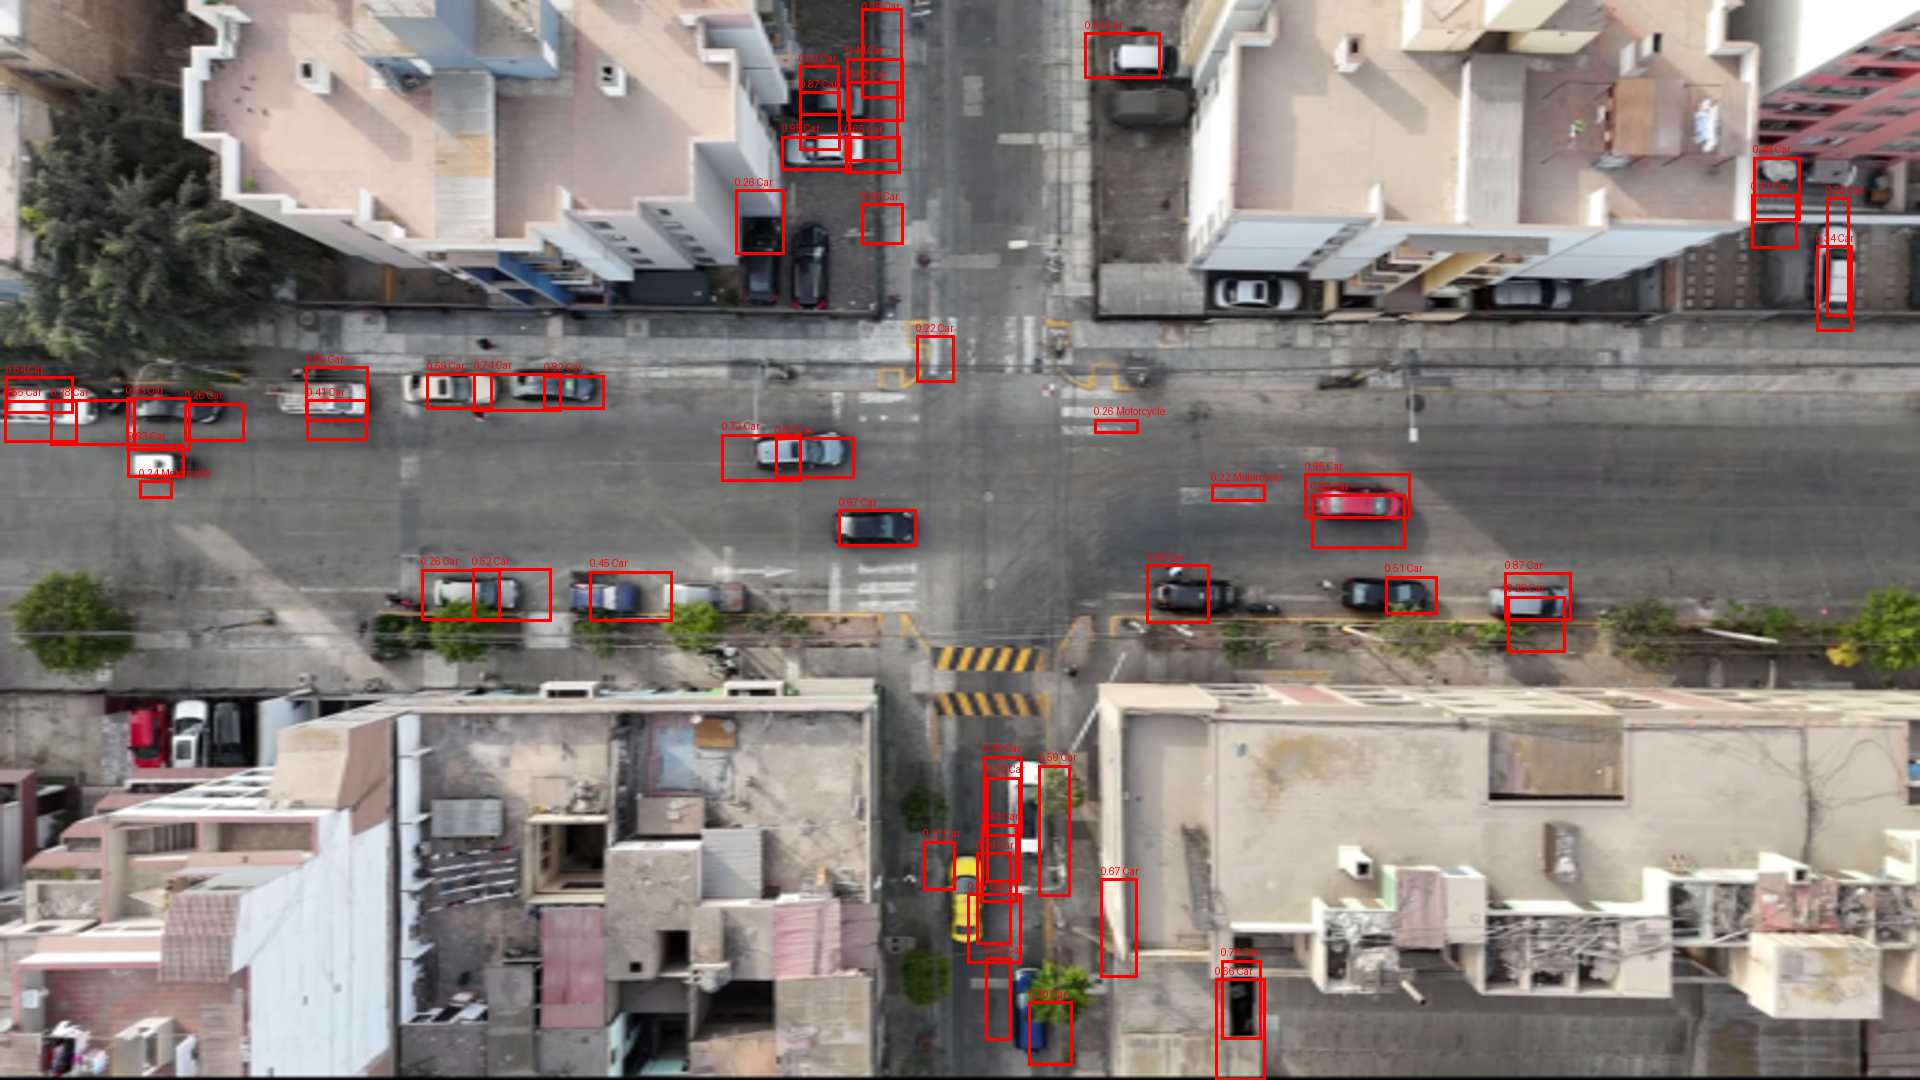

In [7]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return TF.to_pil_image(image.clamp(0, 1))


def draw_detections(image, detections, meta):
    canvas = image.resize((meta['orig_w'], meta['orig_h']))
    draw = ImageDraw.Draw(canvas)
    for d in detections:
        x1 = d['cx'] - d['w'] / 2
        y1 = d['cy'] - d['h'] / 2
        x2 = d['cx'] + d['w'] / 2
        y2 = d['cy'] + d['h'] / 2
        draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
        draw.text((x1, max(0, y1 - 14)), f"{d['score']:.2f} {CLASS_NAMES[d['class_id']]}", fill='red')
    return canvas


preview = draw_detections(denormalize(images[0]), decoded[0], metas[0])
preview

## 8. Export predictions

This writes a CSV with the required `Id,Target` columns. If no prediction passes the threshold for an image, the target is exactly `none`.

In [ ]:
def export_predictions(model, rows, output_csv, conf_threshold=0.25):
    dataset = VehicleDataset(rows, train=False)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)
    model.eval()

    with open(output_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['Id', 'Target'])
        writer.writeheader()

        with torch.no_grad():
            for images, _, metas in loader:
                pred = model(images.to(DEVICE))
                batch_detections = decode_predictions(pred, metas, conf_threshold=conf_threshold)
                for meta, detections in zip(metas, batch_detections):
                    writer.writerow({
                        'Id': meta['id'],
                        'Target': format_detections(detections),
                    })


submission_path = OUTPUT_DIR / 'submission_cpu_baseline.csv'
export_predictions(model, rows, submission_path, conf_threshold=0.25)
print('wrote:', submission_path)

with open(submission_path, newline='') as f:
    for _, line in zip(range(5), f):
        print(line.rstrip())

## 9. Next improvements

This notebook is a baseline that is easy to run on CPU. Accuracy can be improved by increasing epochs, increasing image size, using stronger augmentation, allowing multiple anchors per grid cell, or swapping the tiny backbone for a pretrained torchvision backbone.